# Skin Lesion Classification — ISIC 2019
### Task 1: Transfer-learning CNN comparison → Task 2: Classical classifiers on deep features → Hyperparameter tuning



**Environment:** written for Google Colab with a GPU runtime (`Runtime → Change runtime type → GPU`).

**Design choices made for you (change freely in the `CONFIG` cell):**
- Task 1 uses a **2-phase warmup → fine-tune** schedule for every backbone: `CONFIG["epochs_warmup"]` epochs with the backbone frozen (only the new head trains, at `lr_warmup`) then `CONFIG["epochs_finetune"]` epochs with the whole network unfrozen (at a lower `lr_finetune`, so the pretrained weights aren't wrecked by a big update). Defaults are 2 warmup + 6 fine-tune, per what you asked — drop to 5 fine-tune epochs by editing `CONFIG["epochs_finetune"]` if you'd rather.
- Images are decoded/resized **once** and cached in RAM rather than re-read from disk every epoch x every model (see §2) — this is what actually keeps 8 models x 8 epochs each practical in a lab session.
- Class imbalance is handled with class-weighted loss for the CNNs and `class_weight="balanced"` / `sample_weight` for the classical classifiers.
- Precision/Recall/F1 are **macro-averaged** across classes (fairer than micro-average given the imbalance). AUC is macro one-vs-rest.
- Linear SVM / RBF-SVM are trained on a **stratified subsample** of the training features (`CONFIG["svm_max_train_samples"]`) because both scale very badly with sample count — they're still *evaluated* on the full test set like everything else, so the reported scores stay comparable. Raise the cap if you have GPU/CPU time to spare.

**Because I can't run this against your actual Kaggle download from here**, the data-loading cells auto-detect file/folder names defensively and print what they find — if a path guess is wrong you'll see it immediately and can fix it in one line (clearly marked with `# <-- SET MANUALLY IF WRONG`).

Run cells top to bottom. The first time through, set `CONFIG["subset_fraction"]` to something small (e.g. `0.1`) to smoke-test the whole pipeline in minutes before committing to a full multi-hour run.


## 1. Setup

In [1]:
# Install packages not preinstalled on Colab (safe to re-run)
!pip install -q kagglehub thop xgboost --upgrade


In [2]:
import os, glob, time, copy, random, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as tvm
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
RESAMPLE_BILINEAR = getattr(getattr(Image, "Resampling", Image), "BILINEAR")  # Pillow-version-safe (old and new API)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from thop import profile as thop_profile

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

CONFIG = {
    "seed": SEED,
    "img_size": 224,
    "batch_size": 64,
    "num_workers": min(4, os.cpu_count() or 2),
    "selected_classes": ["MEL", "NV", "BCC", "BKL", "AK"],  # <-- teacher wants 5 classes only; edit this list to change which 5
    "epochs_warmup": 2,            # phase 1: backbone frozen, train only the new head
    "epochs_finetune": 6,          # phase 2: backbone unfrozen, fine-tune the whole network (set to 5 if you'd rather)
    "lr_warmup": 1e-3,
    "lr_finetune": 1e-4,           # smaller LR for fine-tuning so a big update doesn't wreck the pretrained weights
    "subset_fraction": 1.0,        # e.g. 0.1 for a FAST smoke test of the whole pipeline before a full run
    "val_size": 0.15,
    "test_size": 0.15,
    "svm_max_train_samples": 6000, # cap for Linear/RBF SVM training only — raise if you have time to spare
    "cache_images_in_ram": True,   # decode+resize every image ONCE upfront instead of every epoch x every model
                                    # (this is the single biggest speed fix below) — turn off only if you hit a RAM limit
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}
print("Using device:", CONFIG["device"])
if CONFIG["device"] == "cpu":
    print("WARNING: no GPU detected. Fine-tuning 8 CNN backbones on CPU will be very slow — "
          "in Colab go to Runtime > Change runtime type > GPU, or set a small subset_fraction first.")
CONFIG


Using device: cuda


{'seed': 42,
 'img_size': 224,
 'batch_size': 64,
 'num_workers': 2,
 'selected_classes': ['MEL', 'NV', 'BCC', 'BKL', 'AK'],
 'epochs_warmup': 2,
 'epochs_finetune': 6,
 'lr_warmup': 0.001,
 'lr_finetune': 0.0001,
 'subset_fraction': 1.0,
 'val_size': 0.15,
 'test_size': 0.15,
 'svm_max_train_samples': 6000,
 'cache_images_in_ram': True,
 'device': 'cuda'}

## 2. Download & Prepare the ISIC 2019 Dataset

Downloaded directly via `kagglehub` — no manual API token needed. The first run downloads and caches the dataset locally (~25,331 images + ground-truth CSV, several GB, so it can take a while depending on your connection); re-running the cell later in the same session just reuses the cache.


In [3]:
import kagglehub

# Download latest version (cached after the first run)
DATA_DIR = kagglehub.dataset_download("salviohexia/isic-2019-skin-lesion-images-for-classification")
print("Path to dataset files:", DATA_DIR)

print("\nTop-level contents of", DATA_DIR)
for root, dirs, fnames in os.walk(DATA_DIR):
    depth = root[len(DATA_DIR):].count(os.sep)
    if depth <= 1:
        print(root, "->", dirs[:10], f"(+{len(fnames)} files)" if fnames else "")


Using Colab cache for faster access to the 'isic-2019-skin-lesion-images-for-classification' dataset.
Path to dataset files: /kaggle/input/isic-2019-skin-lesion-images-for-classification

Top-level contents of /kaggle/input/isic-2019-skin-lesion-images-for-classification
/kaggle/input/isic-2019-skin-lesion-images-for-classification -> ['MEL', 'VASC', 'SCC', 'DF', 'NV', 'BKL', 'BCC', 'AK'] (+2 files)
/kaggle/input/isic-2019-skin-lesion-images-for-classification/MEL -> [] (+4522 files)
/kaggle/input/isic-2019-skin-lesion-images-for-classification/VASC -> [] (+253 files)
/kaggle/input/isic-2019-skin-lesion-images-for-classification/SCC -> [] (+628 files)
/kaggle/input/isic-2019-skin-lesion-images-for-classification/DF -> [] (+239 files)
/kaggle/input/isic-2019-skin-lesion-images-for-classification/NV -> [] (+12875 files)
/kaggle/input/isic-2019-skin-lesion-images-for-classification/BKL -> [] (+2624 files)
/kaggle/input/isic-2019-skin-lesion-images-for-classification/BCC -> [] (+3323 files

In [4]:
# Auto-detect the ground-truth CSV and the folder containing the actual images.
# If either guess below looks wrong given the printed candidates, just hardcode the
# right path manually (marked below) and re-run from here.

csv_candidates = [p for p in glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)
                   if "ground" in p.lower() or "groundtruth" in p.lower()]
print("Ground-truth CSV candidates found:", csv_candidates)
GT_CSV_PATH = csv_candidates[0] if csv_candidates else None  # <-- SET MANUALLY IF WRONG

# This dataset stores images inside PER-CLASS subfolders (MEL/, NV/, BCC/, AK/, BKL/,
# DF/, VASC/, SCC/) rather than one flat folder, so instead of guessing a single
# "images folder" we index every image under DATA_DIR by its filename (no extension).
# That makes path lookup work no matter how a given Kaggle mirror lays out its folders.
image_paths = (
    glob.glob(f"{DATA_DIR}/**/*.jpg", recursive=True)
    + glob.glob(f"{DATA_DIR}/**/*.jpeg", recursive=True)
    + glob.glob(f"{DATA_DIR}/**/*.png", recursive=True)
)
image_folders = sorted({os.path.dirname(p) for p in image_paths})
IMAGE_INDEX = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths}
if len(IMAGE_INDEX) != len(image_paths):
    print(f"Warning: {len(image_paths) - len(IMAGE_INDEX)} duplicate filenames across folders "
          f"— keeping the last occurrence found for each.")

print(f"Indexed {len(IMAGE_INDEX)} images across {len(image_folders)} folder(s):")
for f in image_folders:
    print(" ", f, f"({len(glob.glob(f'{f}/*.*'))} files)")

print("\nUsing GT_CSV_PATH =", GT_CSV_PATH)
assert GT_CSV_PATH, "Could not auto-detect the ground-truth CSV — set GT_CSV_PATH manually above."
assert len(IMAGE_INDEX) > 0, "Could not find any images under DATA_DIR — check the download."


Ground-truth CSV candidates found: ['/kaggle/input/isic-2019-skin-lesion-images-for-classification/ISIC_2019_Training_GroundTruth.csv']
Indexed 25331 images across 8 folder(s):
  /kaggle/input/isic-2019-skin-lesion-images-for-classification/AK (867 files)
  /kaggle/input/isic-2019-skin-lesion-images-for-classification/BCC (3323 files)
  /kaggle/input/isic-2019-skin-lesion-images-for-classification/BKL (2624 files)
  /kaggle/input/isic-2019-skin-lesion-images-for-classification/DF (239 files)
  /kaggle/input/isic-2019-skin-lesion-images-for-classification/MEL (4522 files)
  /kaggle/input/isic-2019-skin-lesion-images-for-classification/NV (12875 files)
  /kaggle/input/isic-2019-skin-lesion-images-for-classification/SCC (628 files)
  /kaggle/input/isic-2019-skin-lesion-images-for-classification/VASC (253 files)

Using GT_CSV_PATH = /kaggle/input/isic-2019-skin-lesion-images-for-classification/ISIC_2019_Training_GroundTruth.csv


Columns: ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']
Filtered to ['MEL', 'NV', 'BCC', 'BKL', 'AK'] -> kept 24211/25331 images

Class distribution:
label
NV     12875
MEL     4522
BCC     3323
BKL     2624
AK       867
Name: count, dtype: int64

Classes: ['AK', 'BCC', 'BKL', 'MEL', 'NV']  | NUM_CLASSES = 5


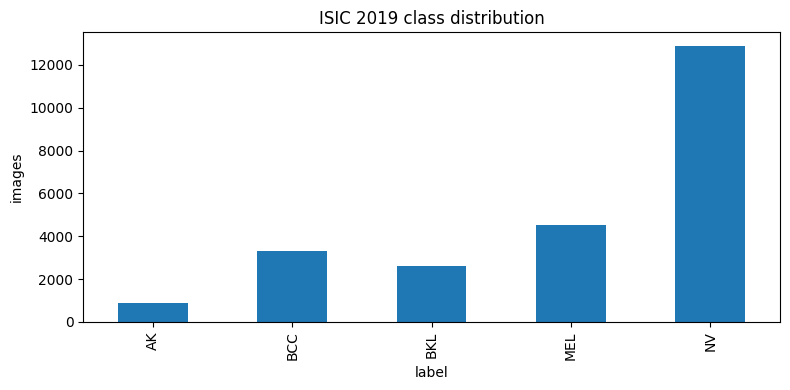

In [5]:
gt = pd.read_csv(GT_CSV_PATH)
print("Columns:", list(gt.columns))

class_cols = [c for c in gt.columns if c.lower() != "image"]
if "UNK" in gt.columns and gt["UNK"].sum() == 0:
    class_cols = [c for c in class_cols if c != "UNK"]  # UNK is unused (always 0) in the ISIC2019 training set

gt["label"] = gt[class_cols].idxmax(axis=1)
gt["filepath"] = gt["image"].map(IMAGE_INDEX)  # looks up across every subfolder, not just one

n_missing = gt["filepath"].isna().sum()
if n_missing:
    print(f"Warning: {n_missing} images listed in the CSV were not found on disk — dropping them.")
gt = gt.dropna(subset=["filepath"]).reset_index(drop=True)

if CONFIG.get("selected_classes"):
    before = len(gt)
    gt = gt[gt["label"].isin(CONFIG["selected_classes"])].reset_index(drop=True)
    print(f"Filtered to {CONFIG['selected_classes']} -> kept {len(gt)}/{before} images")

print("\nClass distribution:")
print(gt["label"].value_counts())

CLASSES = sorted(gt["label"].unique().tolist())
label2idx = {c: i for i, c in enumerate(CLASSES)}
gt["label_idx"] = gt["label"].map(label2idx)
NUM_CLASSES = len(CLASSES)
print("\nClasses:", CLASSES, " | NUM_CLASSES =", NUM_CLASSES)

gt["label"].value_counts().reindex(CLASSES).plot(kind="bar", figsize=(8, 4), title="ISIC 2019 class distribution")
plt.ylabel("images"); plt.tight_layout(); plt.show()


In [6]:
# Optional quick smoke test: shrink the working dataset before splitting
work_df = gt
if CONFIG["subset_fraction"] < 1.0:
    work_df, _ = train_test_split(
        gt, train_size=CONFIG["subset_fraction"], stratify=gt["label_idx"], random_state=CONFIG["seed"]
    )
    work_df = work_df.reset_index(drop=True)
    print(f"Using a {CONFIG['subset_fraction']*100:.0f}% subset: {len(work_df)} images")

train_df, temp_df = train_test_split(
    work_df, test_size=CONFIG["val_size"] + CONFIG["test_size"],
    stratify=work_df["label_idx"], random_state=CONFIG["seed"]
)
val_fraction_of_temp = CONFIG["val_size"] / (CONFIG["val_size"] + CONFIG["test_size"])
val_df, test_df = train_test_split(
    temp_df, train_size=val_fraction_of_temp,
    stratify=temp_df["label_idx"], random_state=CONFIG["seed"]
)
train_df, val_df, test_df = (d.reset_index(drop=True) for d in (train_df, val_df, test_df))
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")


train=16947  val=3632  test=3632


### Why training was slow, and the fix

Task 1 trains **8** architectures for **5** epochs each. Without caching, every one of those 40 epoch-passes re-opens, JPEG-decodes, and resizes the *same* ~21,500 train+val images from scratch — that CPU-side decode/resize cost, not the GPU, is almost always what actually dominates wall-clock time here (a frozen-backbone AlexNet forward pass is a couple of milliseconds per image on any Colab GPU; 13ms/image end-to-end, like the previous run showed, is a decode/resize cost, not a compute one).

The cell below decodes and resizes every image **once**, caches the pixel arrays in RAM, and every model/epoch afterward just reads from that cache — turning ~40 full passes of disk+decode into 1. It costs a few minutes up front and roughly `img_size x img_size x 3` bytes per image (~2GB total for this dataset at 224x224), which fits comfortably in Colab's RAM. Set `CONFIG["cache_images_in_ram"] = False` to fall back to the slower per-epoch decode if you ever hit a memory limit.

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

IMAGE_CACHE = {}
if CONFIG["cache_images_in_ram"]:
    def load_resized(path, size):
        with Image.open(path) as im:
            return np.asarray(im.convert("RGB").resize((size, size), RESAMPLE_BILINEAR), dtype=np.uint8)

    used_paths = pd.concat([train_df, val_df, test_df])["filepath"].unique()
    est_gb = len(used_paths) * (CONFIG["img_size"] ** 2) * 3 / 1e9
    print(f"Caching {len(used_paths)} images at {CONFIG['img_size']}x{CONFIG['img_size']} "
          f"(~{est_gb:.2f} GB in RAM) — one-time cost, this is what actually fixes the slowness.")

    t0 = time.time()
    for i, p in enumerate(used_paths):
        IMAGE_CACHE[p] = load_resized(p, CONFIG["img_size"])
        if (i + 1) % 5000 == 0:
            print(f"  cached {i+1}/{len(used_paths)}  ({(time.time()-t0)/60:.1f} min elapsed)")
    print(f"Done caching {len(IMAGE_CACHE)} images in {(time.time()-t0)/60:.1f} min.")
else:
    print("cache_images_in_ram=False -> decoding from disk every epoch (slower).")

# No T.Resize here: images are already CONFIG['img_size'] x CONFIG['img_size'] by the time
# they reach these transforms (either pre-cached above, or resized on the fly in ISICDataset).
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ISICDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if CONFIG["cache_images_in_ram"]:
            img = Image.fromarray(IMAGE_CACHE[row["filepath"]])
        else:
            with Image.open(row["filepath"]) as im:
                img = im.convert("RGB").resize((CONFIG["img_size"], CONFIG["img_size"]), RESAMPLE_BILINEAR)
        if self.transform:
            img = self.transform(img)
        return img, int(row["label_idx"])

train_ds = ISICDataset(train_df, train_transform)
val_ds = ISICDataset(val_df, eval_transform)
test_ds = ISICDataset(test_df, eval_transform)

_persist = CONFIG["num_workers"] > 0
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=CONFIG["num_workers"], pin_memory=True, persistent_workers=_persist)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True, persistent_workers=_persist)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                          num_workers=CONFIG["num_workers"], pin_memory=True, persistent_workers=_persist)

class_weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=train_df["label_idx"].values)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(CONFIG["device"])
print("Class weights:", dict(zip(CLASSES, class_weights.round(2))))


Caching 24211 images at 224x224 (~3.64 GB in RAM) — one-time cost, this is what actually fixes the slowness.
  cached 5000/24211  (2.0 min elapsed)
  cached 10000/24211  (3.8 min elapsed)
  cached 15000/24211  (5.6 min elapsed)
  cached 20000/24211  (7.5 min elapsed)
Done caching 24211 images in 9.0 min.
Class weights: {'AK': np.float64(5.58), 'BCC': np.float64(1.46), 'BKL': np.float64(1.85), 'MEL': np.float64(1.07), 'NV': np.float64(0.38)}


## 3. Task 1 — Transfer-Learning Backbone Comparison (→ Table 1)

Eight ImageNet-pretrained backbones, each given a fresh `Linear` classification head for our `NUM_CLASSES` (5, per §2). Each one goes through the same 2-phase schedule: **warmup** (`CONFIG["epochs_warmup"]` epochs, backbone frozen, only the new head trains) then **fine-tune** (`CONFIG["epochs_finetune"]` epochs, whole network unfrozen at a lower learning rate).

In [8]:
MODEL_NAMES = ["alexnet", "vgg16", "vgg19", "resnet18", "resnet50", "resnet101", "densenet121", "efficientnet_b0"]

def get_head_module(model, name):
    if name in ("alexnet", "vgg16", "vgg19"):
        return model.classifier[6]
    if name in ("resnet18", "resnet50", "resnet101"):
        return model.fc
    if name == "densenet121":
        return model.classifier
    if name == "efficientnet_b0":
        return model.classifier[1]
    raise ValueError(name)

def build_model(name, num_classes, freeze_backbone=True):
    if name == "alexnet":
        model = tvm.alexnet(weights=tvm.AlexNet_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif name == "vgg16":
        model = tvm.vgg16(weights=tvm.VGG16_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif name == "vgg19":
        model = tvm.vgg19(weights=tvm.VGG19_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif name == "resnet18":
        model = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "resnet50":
        model = tvm.resnet50(weights=tvm.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "resnet101":
        model = tvm.resnet101(weights=tvm.ResNet101_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "densenet121":
        model = tvm.densenet121(weights=tvm.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif name == "efficientnet_b0":
        model = tvm.efficientnet_b0(weights=tvm.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model name: {name}")

    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
        for p in get_head_module(model, name).parameters():
            p.requires_grad = True

    return model

def get_feature_extractor(model, name):
    '''Returns a copy of `model` with its final classification layer replaced by
    Identity, so forward() yields the penultimate-layer feature vector directly.'''
    fe = copy.deepcopy(model)
    if name in ("alexnet", "vgg16", "vgg19"):
        fe.classifier[6] = nn.Identity()
    elif name in ("resnet18", "resnet50", "resnet101"):
        fe.fc = nn.Identity()
    elif name == "densenet121":
        fe.classifier = nn.Identity()
    elif name == "efficientnet_b0":
        fe.classifier[1] = nn.Identity()
    fe.eval()
    return fe


In [9]:
def train_model(model, train_loader, val_loader, epochs, lr, class_weights, device, phase_label=""):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)
    tag = f"[{phase_label}] " if phase_label else ""

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)
        print(f"  {tag}epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

    return model

def train_model_warmup_finetune(model, train_loader, val_loader, config, class_weights, device):
    '''Phase 1 (warmup): model arrives with the backbone frozen (built via
    build_model(..., freeze_backbone=True)) -- only the new head trains.
    Phase 2 (fine-tune): unfreeze everything and keep training at a lower LR,
    so the big early gradients from an untrained head don't blow up the
    pretrained weights before they've had a chance to settle.'''
    if config["epochs_warmup"] > 0:
        model = train_model(model, train_loader, val_loader, config["epochs_warmup"],
                             config["lr_warmup"], class_weights, device, phase_label="warmup")

    if config["epochs_finetune"] > 0:
        for p in model.parameters():
            p.requires_grad = True
        model = train_model(model, train_loader, val_loader, config["epochs_finetune"],
                             config["lr_finetune"], class_weights, device, phase_label="finetune")

    return model

def evaluate_model(model, loader, num_classes, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(probs.argmax(axis=1))
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)
    acc = (all_preds == all_labels).mean()
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro", labels=np.arange(num_classes))
    except ValueError:
        auc = float("nan")

    return {
        "Accuracy (%)": acc * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1-Score (%)": f1 * 100,
        "AUC (%)": auc * 100,
    }


In [10]:
task1_results = []
task1_trained_models = {}

for name in MODEL_NAMES:
    print(f"\n=== Task 1: training {name} ===")
    t0 = time.time()
    model = build_model(name, NUM_CLASSES, freeze_backbone=True)  # always start frozen for the warmup phase
    model = train_model_warmup_finetune(model, train_loader, val_loader, CONFIG,
                                         class_weights_tensor, CONFIG["device"])
    metrics = evaluate_model(model, test_loader, NUM_CLASSES, CONFIG["device"])
    elapsed_min = (time.time() - t0) / 60

    task1_results.append({"Model": name, **metrics})
    task1_trained_models[name] = model.cpu()
    torch.save(model.state_dict(), f"/content/{name}_task1.pt")
    print(f"{name}: {metrics}  (took {elapsed_min:.1f} min)")

    if CONFIG["device"] == "cuda":
        torch.cuda.empty_cache()

table1_df = pd.DataFrame(task1_results)[["Model", "Accuracy (%)", "Precision (%)", "Recall (%)", "F1-Score (%)", "AUC (%)"]]
table1_df = table1_df.round(2)
table1_df.to_csv("/content/table1_transfer_learning_models.csv", index=False)
table1_df



=== Task 1: training alexnet ===
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 175MB/s]


  [warmup] epoch 1/2  train_loss=1.2983  val_loss=1.1650  val_acc=0.5622
  [warmup] epoch 2/2  train_loss=1.2434  val_loss=1.1574  val_acc=0.6079
  [finetune] epoch 1/6  train_loss=1.1057  val_loss=0.9761  val_acc=0.6322
  [finetune] epoch 2/6  train_loss=0.9652  val_loss=0.9923  val_acc=0.5540
  [finetune] epoch 3/6  train_loss=0.8792  val_loss=0.9034  val_acc=0.6490
  [finetune] epoch 4/6  train_loss=0.8015  val_loss=0.8426  val_acc=0.6988
  [finetune] epoch 5/6  train_loss=0.7565  val_loss=0.8635  val_acc=0.7081
  [finetune] epoch 6/6  train_loss=0.6869  val_loss=0.8082  val_acc=0.6531
alexnet: {'Accuracy (%)': np.float64(65.08810572687224), 'Precision (%)': 58.15801644114933, 'Recall (%)': 68.58328178685393, 'F1-Score (%)': 60.187110579974146, 'AUC (%)': np.float64(91.10833678646284)}  (took 5.5 min)

=== Task 1: training vgg16 ===
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 111MB/s]


  [warmup] epoch 1/2  train_loss=1.3969  val_loss=1.2939  val_acc=0.5333
  [warmup] epoch 2/2  train_loss=1.3538  val_loss=1.3236  val_acc=0.3665
  [finetune] epoch 1/6  train_loss=1.1902  val_loss=1.0528  val_acc=0.5526
  [finetune] epoch 2/6  train_loss=0.9932  val_loss=0.8988  val_acc=0.6759
  [finetune] epoch 3/6  train_loss=0.9043  val_loss=0.8421  val_acc=0.7062
  [finetune] epoch 4/6  train_loss=0.8266  val_loss=0.8159  val_acc=0.7087
  [finetune] epoch 5/6  train_loss=0.7322  val_loss=0.7966  val_acc=0.7379
  [finetune] epoch 6/6  train_loss=0.6838  val_loss=0.8373  val_acc=0.7079
vgg16: {'Accuracy (%)': np.float64(71.36563876651982), 'Precision (%)': 63.05411591757546, 'Recall (%)': 70.0023601033652, 'F1-Score (%)': 65.0780487433647, 'AUC (%)': np.float64(92.56725977371774)}  (took 31.7 min)

=== Task 1: training vgg19 ===
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


...

100%|██████████| 30.8M/30.8M [00:00<00:00, 54.4MB/s]


  [warmup] epoch 1/2  train_loss=1.2080  val_loss=1.1280  val_acc=0.5209
  [warmup] epoch 2/2  train_loss=1.0817  val_loss=1.1060  val_acc=0.5567
  [finetune] epoch 1/6  train_loss=0.9121  val_loss=0.8039  val_acc=0.7048
  [finetune] epoch 2/6  train_loss=0.6741  val_loss=0.7379  val_acc=0.7483
  [finetune] epoch 3/6  train_loss=0.5480  val_loss=0.6683  val_acc=0.7373
  [finetune] epoch 4/6  train_loss=0.4179  val_loss=0.6655  val_acc=0.7720
  [finetune] epoch 5/6  train_loss=0.3441  val_loss=0.6844  val_acc=0.8007
  [finetune] epoch 6/6  train_loss=0.2910  val_loss=0.6919  val_acc=0.8084
densenet121: {'Accuracy (%)': np.float64(80.94713656387665), 'Precision (%)': 72.2787034311701, 'Recall (%)': 76.74762987616239, 'F1-Score (%)': 73.60226379762128, 'AUC (%)': np.float64(95.01821963068974)}  (took 21.1 min)

=== Task 1: training efficientnet_b0 ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientne

100%|██████████| 20.5M/20.5M [00:00<00:00, 140MB/s]


  [warmup] epoch 1/2  train_loss=1.2045  val_loss=1.1227  val_acc=0.5380
  [warmup] epoch 2/2  train_loss=1.0829  val_loss=1.0958  val_acc=0.5768
  [finetune] epoch 1/6  train_loss=0.9339  val_loss=0.8173  val_acc=0.7070
  [finetune] epoch 2/6  train_loss=0.7183  val_loss=0.7419  val_acc=0.7258
  [finetune] epoch 3/6  train_loss=0.5980  val_loss=0.6982  val_acc=0.7596
  [finetune] epoch 4/6  train_loss=0.4944  val_loss=0.6594  val_acc=0.7544
  [finetune] epoch 5/6  train_loss=0.4220  val_loss=0.6638  val_acc=0.7632
  [finetune] epoch 6/6  train_loss=0.3401  val_loss=0.6646  val_acc=0.7919
efficientnet_b0: {'Accuracy (%)': np.float64(81.08480176211454), 'Precision (%)': 73.87066961396336, 'Recall (%)': 77.77914189231475, 'F1-Score (%)': 75.64807803712232, 'AUC (%)': np.float64(95.47872442191897)}  (took 10.6 min)


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
0,alexnet,65.09,58.16,68.58,60.19,91.11
1,vgg16,71.37,63.05,70.00,65.08,92.57
2,vgg19,64.29,58.14,64.84,55.27,89.59
3,resnet18,76.71,67.42,75.26,70.32,94.34
4,resnet50,81.19,73.37,76.41,74.56,95.91
5,resnet101,80.89,73.92,79.86,76.36,96.17
6,densenet121,80.95,72.28,76.75,73.60,95.02
7,efficientnet_b0,81.08,73.87,77.78,75.65,95.48


### Pick the best Task 1 model

Selection is by **Accuracy** (first column of Table 1) — change the sort column below if you'd rather select by F1 or AUC.

In [11]:
BEST_MODEL_NAME = table1_df.sort_values("Accuracy (%)", ascending=False).iloc[0]["Model"]
print("Best Task 1 model:", BEST_MODEL_NAME)
table1_df.sort_values("Accuracy (%)", ascending=False)


Best Task 1 model: resnet50


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
4,resnet50,81.19,73.37,76.41,74.56,95.91
7,efficientnet_b0,81.08,73.87,77.78,75.65,95.48
6,densenet121,80.95,72.28,76.75,73.60,95.02
5,resnet101,80.89,73.92,79.86,76.36,96.17
3,resnet18,76.71,67.42,75.26,70.32,94.34
1,vgg16,71.37,63.05,70.00,65.08,92.57
0,alexnet,65.09,58.16,68.58,60.19,91.11
2,vgg19,64.29,58.14,64.84,55.27,89.59


## 4. Extract Deep Features from the Best Task 1 Model

In [12]:
best_model = task1_trained_models[BEST_MODEL_NAME].to(CONFIG["device"])
feature_extractor = get_feature_extractor(best_model, BEST_MODEL_NAME).to(CONFIG["device"])

def extract_features(loader, extractor, device):
    feats, labels = [], []
    extractor.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            out = extractor(imgs)
            out = out.view(out.size(0), -1)
            feats.append(out.cpu().numpy())
            labels.append(lbls.numpy())
    return np.concatenate(feats), np.concatenate(labels)

X_train, y_train = extract_features(train_loader, feature_extractor, CONFIG["device"])
X_test, y_test = extract_features(test_loader, feature_extractor, CONFIG["device"])

np.save("/content/X_train.npy", X_train); np.save("/content/y_train.npy", y_train)
np.save("/content/X_test.npy", X_test); np.save("/content/y_test.npy", y_test)
print("Feature shapes — train:", X_train.shape, " test:", X_test.shape)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)


Feature shapes — train: (16947, 2048)  test: (3632, 2048)


## 5. Task 2 — Classical Classifiers on Deep Features (→ Table 2)

Same train/test split and features for every classifier, so results are directly comparable. Linear/RBF SVM train on a stratified subsample (`CONFIG["svm_max_train_samples"]`) for tractability but are evaluated on the *full* test set like everything else.

In [13]:
if len(X_train_s) > CONFIG["svm_max_train_samples"]:
    X_train_svm, _, y_train_svm, _ = train_test_split(
        X_train_s, y_train,
        train_size=CONFIG["svm_max_train_samples"],
        stratify=y_train, random_state=CONFIG["seed"],
    )
else:
    X_train_svm, y_train_svm = X_train_s, y_train
print("SVM training subsample size:", len(X_train_svm))

sample_weight_train = compute_sample_weight("balanced", y_train)

# name -> (estimator, X_train, y_train, fit_sample_weight_or_None)
CLASSIFIERS = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, class_weight="balanced"), X_train_s, y_train, None),
    "Decision Tree": (
        DecisionTreeClassifier(class_weight="balanced", random_state=CONFIG["seed"]), X_train_s, y_train, None),
    "Random Forest": (
        RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=CONFIG["seed"], n_jobs=-1),
        X_train_s, y_train, None),
    "K-Nearest Neighbors (KNN)": (
        KNeighborsClassifier(n_neighbors=5), X_train_s, y_train, None),
    "Linear SVM": (
        SVC(kernel="linear", probability=True, class_weight="balanced", random_state=CONFIG["seed"]),
        X_train_svm, y_train_svm, None),
    "RBF-SVM": (
        SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=CONFIG["seed"]),
        X_train_svm, y_train_svm, None),
    "XGBoost": (
        XGBClassifier(n_estimators=200, eval_metric="mlogloss", random_state=CONFIG["seed"]),
        X_train_s, y_train, sample_weight_train),
}

def evaluate_sklearn(clf, X_test, y_test, num_classes):
    preds = clf.predict(X_test)
    probs = clf.predict_proba(X_test)
    acc = (preds == y_test).mean()
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds, average="macro", zero_division=0)
    try:
        auc = roc_auc_score(y_test, probs, multi_class="ovr", average="macro", labels=np.arange(num_classes))
    except ValueError:
        auc = float("nan")
    return {
        "Accuracy (%)": acc * 100, "Precision (%)": precision * 100,
        "Recall (%)": recall * 100, "F1-Score (%)": f1 * 100, "AUC (%)": auc * 100,
    }


SVM training subsample size: 6000


In [14]:
task2_results = []
trained_classifiers = {}

for cname, (clf, Xtr, ytr, sw) in CLASSIFIERS.items():
    print(f"\n=== Task 2: training {cname} ===")
    t0 = time.time()
    if sw is not None:
        clf.fit(Xtr, ytr, sample_weight=sw)
    else:
        clf.fit(Xtr, ytr)
    metrics = evaluate_sklearn(clf, X_test_s, y_test, NUM_CLASSES)
    elapsed = time.time() - t0

    task2_results.append({"Feature Extractor": "Deep Features", "Classifier": cname, **metrics})
    trained_classifiers[cname] = clf
    print(f"{cname}: {metrics}  (took {elapsed:.1f}s)")

table2_df = pd.DataFrame(task2_results)[
    ["Feature Extractor", "Classifier", "Accuracy (%)", "Precision (%)", "Recall (%)", "F1-Score (%)", "AUC (%)"]
].round(2)
table2_df.to_csv("/content/table2_classifier_comparison.csv", index=False)
table2_df



=== Task 2: training Logistic Regression ===
Logistic Regression: {'Accuracy (%)': np.float64(81.77312775330397), 'Precision (%)': 76.78746951921892, 'Recall (%)': 74.74701155397565, 'F1-Score (%)': 75.68585502222372, 'AUC (%)': np.float64(94.94837920829333)}  (took 21.3s)

=== Task 2: training Decision Tree ===
Decision Tree: {'Accuracy (%)': np.float64(68.03414096916299), 'Precision (%)': 59.199588632243305, 'Recall (%)': 57.745424453175566, 'F1-Score (%)': 58.43117847545691, 'AUC (%)': np.float64(73.90272476353736)}  (took 96.3s)

=== Task 2: training Random Forest ===
Random Forest: {'Accuracy (%)': np.float64(79.15748898678414), 'Precision (%)': 79.56145219404827, 'Recall (%)': 66.7455124855167, 'F1-Score (%)': 71.19810704944405, 'AUC (%)': np.float64(94.89135932899316)}  (took 156.1s)

=== Task 2: training K-Nearest Neighbors (KNN) ===
K-Nearest Neighbors (KNN): {'Accuracy (%)': np.float64(82.37885462555066), 'Precision (%)': 79.01396842944591, 'Recall (%)': 74.34441487666929, '

,Feature Extractor,Classifier,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
0,Deep Features,Logistic Regression,81.77,76.79,74.75,75.69,94.95
1,Deep Features,Decision Tree,68.03,59.20,57.75,58.43,73.90
2,Deep Features,Random Forest,79.16,79.56,66.75,71.20,94.89
3,Deep Features,K-Nearest Neighbors (KNN),82.38,79.01,74.34,75.92,91.85
4,Deep Features,Linear SVM,82.30,78.55,75.53,76.81,95.29
5,Deep Features,RBF-SVM,82.98,78.07,77.71,77.83,95.40
6,Deep Features,XGBoost,82.90,77.24,75.35,76.18,95.61


In [15]:
BEST_CLASSIFIER_NAME = table2_df.sort_values("Accuracy (%)", ascending=False).iloc[0]["Classifier"]
print("Best Task 2 classifier:", BEST_CLASSIFIER_NAME)
table2_df.sort_values("Accuracy (%)", ascending=False)


Best Task 2 classifier: RBF-SVM


,Feature Extractor,Classifier,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
5,Deep Features,RBF-SVM,82.98,78.07,77.71,77.83,95.40
6,Deep Features,XGBoost,82.90,77.24,75.35,76.18,95.61
3,Deep Features,K-Nearest Neighbors (KNN),82.38,79.01,74.34,75.92,91.85
4,Deep Features,Linear SVM,82.30,78.55,75.53,76.81,95.29
0,Deep Features,Logistic Regression,81.77,76.79,74.75,75.69,94.95
2,Deep Features,Random Forest,79.16,79.56,66.75,71.20,94.89
1,Deep Features,Decision Tree,68.03,59.20,57.75,58.43,73.90


## 6. Hyperparameter Tuning of the Best Classifier ("try to change parameters")

Runs a grid search (3-fold CV, scored on accuracy) over a sensible parameter grid for whichever classifier won Task 2, then compares default vs. tuned performance on the held-out test set. The grid below covers all seven classifiers so this cell works no matter which one won.

In [ ]:
PARAM_GRIDS = {
    "Logistic Regression": {"C": [0.01, 0.1, 1, 10, 100]},
    "Decision Tree": {"max_depth": [5, 10, 20, None], "min_samples_split": [2, 5, 10]},
    "Random Forest": {"n_estimators": [100, 200, 400], "max_depth": [None, 10, 20], "min_samples_split": [2, 5]},
    "K-Nearest Neighbors (KNN)": {"n_neighbors": [3, 5, 7, 11, 15], "weights": ["uniform", "distance"]},
    "Linear SVM": {"C": [0.01, 0.1, 1, 10]},
    "RBF-SVM": {"C": [0.1, 1, 10, 100], "gamma": ["scale", 0.01, 0.001]},
    "XGBoost": {"n_estimators": [100, 200, 400], "max_depth": [3, 6, 9], "learning_rate": [0.01, 0.1, 0.2]},
}

base_clf, Xtr, ytr, _ = CLASSIFIERS[BEST_CLASSIFIER_NAME]
grid = PARAM_GRIDS[BEST_CLASSIFIER_NAME]
print(f"Tuning {BEST_CLASSIFIER_NAME} over grid: {grid}")

search = GridSearchCV(base_clf, grid, scoring="accuracy", cv=3, n_jobs=-1, verbose=1)
search.fit(Xtr, ytr)
print("\nBest params found:", search.best_params_)
print("Best CV accuracy:", search.best_score_)

tuned_clf = search.best_estimator_
tuned_metrics = evaluate_sklearn(tuned_clf, X_test_s, y_test, NUM_CLASSES)

comparison_df = pd.DataFrame([
    {"Version": f"{BEST_CLASSIFIER_NAME} (default params)", **evaluate_sklearn(trained_classifiers[BEST_CLASSIFIER_NAME], X_test_s, y_test, NUM_CLASSES)},
    {"Version": f"{BEST_CLASSIFIER_NAME} (tuned: {search.best_params_})", **tuned_metrics},
]).round(2)
comparison_df


Tuning RBF-SVM over grid: {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.001]}
Fitting 3 folds for each of 12 candidates, totalling 36 fits


## 7. Computational Efficiency Comparison (→ Table 3)

Parameters, on-disk size, FLOPs, and single-image inference time for the 7 models listed in Table 3 (ResNet101 isn't in that table, so it's skipped here). Accuracy is pulled straight from Table 1.

Note: `thop` doesn't have exact FLOP counters for every layer type in newer architectures (e.g. some of EfficientNet's blocks) — treat FLOPs as approximate; `ptflops` or `fvcore` are alternatives if you want to cross-check.

In [ ]:
EFF_MODEL_NAMES = ["alexnet", "vgg16", "vgg19", "resnet18", "resnet50", "densenet121", "efficientnet_b0"]

def measure_efficiency(name, num_classes, device, img_size=224, n_timing_runs=30):
    model = build_model(name, num_classes).to(device)
    model.eval()
    dummy = torch.randn(1, 3, img_size, img_size).to(device)

    n_params_m = sum(p.numel() for p in model.parameters()) / 1e6

    tmp_path = f"/content/_tmp_{name}.pt"
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 ** 2)
    os.remove(tmp_path)

    macs, _ = thop_profile(model, inputs=(dummy,), verbose=False)
    gflops = 2 * macs / 1e9  # convention: FLOPs ~= 2 x MACs

    with torch.no_grad():
        for _ in range(5):
            _ = model(dummy)
        if device == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(n_timing_runs):
            _ = model(dummy)
        if device == "cuda":
            torch.cuda.synchronize()
        ms_per_image = (time.time() - t0) / n_timing_runs * 1000

    del model
    if device == "cuda":
        torch.cuda.empty_cache()

    return {"Parameters (M)": n_params_m, "Model Size (MB)": size_mb, "FLOPs (G)": gflops, "Inference Time (ms)": ms_per_image}

acc_lookup = table1_df.set_index("Model")["Accuracy (%)"].to_dict()

task3_results = []
for name in EFF_MODEL_NAMES:
    print("Measuring efficiency:", name)
    eff = measure_efficiency(name, NUM_CLASSES, CONFIG["device"])
    task3_results.append({"Model": name, **eff, "Accuracy (%)": acc_lookup.get(name, float("nan"))})

table3_df = pd.DataFrame(task3_results)[
    ["Model", "Parameters (M)", "Model Size (MB)", "FLOPs (G)", "Inference Time (ms)", "Accuracy (%)"]
].round(3)
table3_df.to_csv("/content/table3_efficiency_comparison.csv", index=False)
table3_df


## 8. Bonus — Confusion Matrices (not in the tables, but useful for the write-up)

Quick visual for the best CNN (Task 1) and the final tuned classifier (Task 2 + §6), since these are usually expected in the discussion section of the report.

In [ ]:
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black", fontsize=8)
    fig.colorbar(im)
    plt.tight_layout(); plt.show()

# Best CNN (Task 1)
best_model.eval().to(CONFIG["device"])
with torch.no_grad():
    cnn_preds, cnn_true = [], []
    for imgs, labels in test_loader:
        outputs = best_model(imgs.to(CONFIG["device"]))
        cnn_preds.extend(outputs.argmax(1).cpu().numpy())
        cnn_true.extend(labels.numpy())
plot_confusion(cnn_true, cnn_preds, CLASSES, f"Task 1 best model: {BEST_MODEL_NAME}")

# Final tuned classifier (Task 2 + §6)
tuned_preds = tuned_clf.predict(X_test_s)
plot_confusion(y_test, tuned_preds, CLASSES, f"Tuned {BEST_CLASSIFIER_NAME} (Task 2)")


## 9. Summary

```
table1_df       -> Table 1 (Comparison of Transfer Learning Models)
table2_df       -> Table 2 (Comparison of Different Classifiers)
comparison_df   -> default vs. tuned best classifier
table3_df       -> Table 3 (Computational Efficiency Comparison)
```

All four are also saved as CSVs under `/content/` — download them (`files.download("/content/table1_transfer_learning_models.csv")`, etc.) or just copy the printed numbers straight into the Word doc tables.

**When you're done running this:** send back the four tables/outputs (screenshots or the CSVs) plus which model/classifier ended up best — that's everything needed to fill in Task 01.docx and write up the results.
